# Storm Event Window Analysis

Persistence metrics ($P_{\max}$, $TP_1$, $TP_2$) for every day in a ±10-day
window around the sublevel-set storm trajectory
**2012-01-31 → 2012-02-05** (trajectory ID 31802).

All persistence values are in **hPa** (raw data is in Pa; divided by 100 on load).

| Metric | Definition |
|--------|------------|
| $P_{\max}$ | $\max_i\,\lvert b_i - d_i\rvert$ |
| $TP_1$ | $\sum_i\,\lvert b_i - d_i\rvert$ |
| $TP_2$ | $\sum_i\,\lvert b_i - d_i\rvert^2$ |

In [27]:
import pandas as pd
import numpy as np
import os
import sys
import importlib
import matplotlib.pyplot as plt
from datetime import date, timedelta


In [28]:
# Resolve project root (works whether run from /notebook or the project root)
notebook_directory = os.path.abspath(
    os.path.join(os.getcwd(), '..')
    if os.path.basename(os.getcwd()) == 'notebook'
    else os.getcwd()
)
print('Project root:', notebook_directory)

sys.path.append(os.path.join(notebook_directory, 'src'))
import feature_tracking
importlib.reload(feature_tracking)


Project root: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate


<module 'feature_tracking' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/feature_tracking.py'>

In [29]:
# ── Event and window parameters ─────────────────────────────────────────────
EVENT_START = pd.Timestamp('2012-01-31')
EVENT_END   = pd.Timestamp('2012-02-05')
WINDOW      = 10   # days before / after

t0 = EVENT_START - pd.Timedelta(days=WINDOW)   # 2012-01-21
t1 = EVENT_END   + pd.Timedelta(days=WINDOW)   # 2012-02-15

window_dates = pd.date_range(t0, t1, freq='D')

# Map (year, day-of-year) → metadata
date_meta = {}
for d in window_dates:
    doy = (d - pd.Timestamp(f'{d.year}-01-01')).days + 1
    t_offset = (d - EVENT_START).days
    event_phase = (
        'pre-event'   if d < EVENT_START else
        'event'       if d <= EVENT_END  else
        'post-event'
    )
    date_meta[(d.year, doy)] = dict(date=d, t_offset=t_offset, event_phase=event_phase)

years = list({k[0] for k in date_meta})
doys  = list({k[1] for k in date_meta})

print(f'Window  : {t0.date()}  →  {t1.date()}  ({len(window_dates)} days)')
print(f'Event   : {EVENT_START.date()}  →  {EVENT_END.date()}')
print(f'Years   : {years}')
print(f'Day-of-year range: {min(doys)} – {max(doys)}')


Window  : 2012-01-21  →  2012-02-15  (26 days)
Event   : 2012-01-31  →  2012-02-05
Years   : [2012]
Day-of-year range: 21 – 46


In [30]:
# ════════════════════════════════════════════════════════════════════════════
# PLOT CONFIGURATION  —  change FONTSIZE here to rescale all plot text
# ════════════════════════════════════════════════════════════════════════════
FONTSIZE = 12

import matplotlib.dates as mdates

plt.rcParams.update({
    'font.size':        FONTSIZE,
    'axes.titlesize':   FONTSIZE,
    'axes.labelsize':   FONTSIZE,
    'xtick.labelsize':  FONTSIZE - 2,
    'ytick.labelsize':  FONTSIZE - 2,
    'legend.fontsize':  FONTSIZE - 2,
    'figure.titlesize': FONTSIZE + 1,
})

# Output directory — February 2012 sub-folder
out_dir = os.path.join(notebook_directory, 'output', 'figures', 'blocking_event', 'february_2012')
os.makedirs(out_dir, exist_ok=True)

# B&W line styles
STYLES = {
    'sub': dict(color='black', ls=':',  marker='o', ms=5, lw=1.8, label='anticyclone'),
    'sup': dict(color='black', ls='-',  marker='o', ms=5, lw=1.8, label='cyclone'),
}

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

def shade_event(ax):
    ax.axvspan(EVENT_START, EVENT_END, alpha=0.12, color='gray')
    ax.axvline(EVENT_START, color='gray', lw=1.2, ls=':')
    ax.axvline(EVENT_END,   color='gray', lw=1.2, ls=':')

# ════════════════════════════════════════════════════════════════════════════
# SHARED Y-AXIS LIMITS — set the same values in notebook 10 to compare events
# None = auto-scale; set an integer/float to fix the axis.
# ════════════════════════════════════════════════════════════════════════════
PMAX_YMAX    = 60   # Fig: P_max (hPa)              e.g. 60
TP1_YMAX     = 200   # Fig: TP_1 (hPa)               e.g. 250
TP2_YMAX     = 4000   # Fig: TP_2 (hPa²)              e.g. 4000
N_TAU_YMAX   = 8   # Fig 14: No. of structures     e.g. 10
WASS_YMAX    = 100   # Fig 15: Wasserstein distance   e.g. 110
AREA_YMAX    = 260   # Fig: area (×10⁶ km²)          e.g. 250

print(f'Font size : {FONTSIZE}')
print(f'Output dir: {out_dir}')

Font size : 12
Output dir: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/output/figures/blocking_event/february_2012


In [31]:
# ── Load persistence features for every day in the window ───────────────────
df_raw = feature_tracking.load_all_representative_data_to_df(
    years=years,
    days=doys,
    data_types=['sub', 'sup'],
    notebook_dir=notebook_directory
)

df_raw['date']        = df_raw.apply(lambda r: date_meta[(r['year'], r['day'])]['date'],        axis=1)
df_raw['t_offset']    = df_raw.apply(lambda r: date_meta[(r['year'], r['day'])]['t_offset'],    axis=1)
df_raw['event_phase'] = df_raw.apply(lambda r: date_meta[(r['year'], r['day'])]['event_phase'], axis=1)

# Raw values are in Pa; convert to hPa (consistent with feature_tracking plotting)
df_raw['birth']       = df_raw['birth']       / 100.0
df_raw['death']       = df_raw['death']       / 100.0
df_raw['persistence'] = df_raw['persistence'] / 100.0

df_window = (
    df_raw
    .sort_values(['t_offset', 'data_type', 'persistence'], ascending=[True, True, False])
    .reset_index(drop=True)
)

print(f'Total features loaded : {len(df_window)}')
print(f'  sublevel  (sub) : {(df_window["data_type"]=="sub").sum()}')
print(f'  superlevel (sup): {(df_window["data_type"]=="sup").sum()}')
df_window[['date','t_offset','event_phase','data_type','feature_index','birth','death','persistence']].head(20)

Total features loaded : 5460
  sublevel  (sub) : 2630
  superlevel (sup): 2830


,date,t_offset,event_phase,data_type,feature_index,birth,death,persistence
0,2012-01-21,-10,pre-event,sub,80,-4.687470,26.784175,31.471645
1,2012-01-21,-10,pre-event,sub,79,5.585861,26.777791,21.191929
2,2012-01-21,-10,pre-event,sub,78,11.670499,22.224517,10.554017
3,2012-01-21,-10,pre-event,sub,77,18.033658,25.057744,7.024086
4,2012-01-21,-10,pre-event,sub,76,12.395446,18.966567,6.571122
5,2012-01-21,-10,pre-event,sub,75,14.804615,20.552622,5.748007
6,2012-01-21,-10,pre-event,sub,74,0.148852,5.581138,5.432286
7,2012-01-21,-10,pre-event,sub,73,5.511746,8.674515,3.162770
8,2012-01-21,-10,pre-event,sub,72,14.776362,17.498054,2.721692
9,2012-01-21,-10,pre-event,sub,71,3.081273,5.644824,2.563551


In [32]:
# ── Per-day summary: P_max, TP_1, TP_2  (all values in hPa) ─────────────────
def tp2(x):
    return float((x**2).sum())

summary = (
    df_window
    .groupby(['date', 't_offset', 'event_phase', 'data_type'])
    .agg(
        n_features = ('persistence', 'count'),
        P_max      = ('persistence', 'max'),
        TP_1       = ('persistence', 'sum'),
        TP_2       = ('persistence', tp2),
    )
    .round(4)
    .reset_index()
    .sort_values(['t_offset', 'data_type'])
    .reset_index(drop=True)
)

summary['t_label'] = summary['t_offset'].apply(
    lambda x: f't{x:+d}' if x != 0 else 't0 (event start)'
)

summary[['date', 't_label', 'event_phase', 'data_type', 'n_features', 'P_max', 'TP_1', 'TP_2']]

,date,t_label,event_phase,data_type,n_features,P_max,TP_1,TP_2
0,2012-01-21,t-10,pre-event,sub,81,31.4716,111.8988,1741.0520
1,2012-01-21,t-10,pre-event,sup,97,34.4311,145.3551,2684.5593
2,2012-01-22,t-9,pre-event,sub,92,24.0852,91.9099,1081.9528
3,2012-01-22,t-9,pre-event,sup,102,35.3784,147.4433,2496.3988
4,2012-01-23,t-8,pre-event,sub,113,16.9728,93.0590,766.6917
5,2012-01-23,t-8,pre-event,sup,85,30.6316,157.2779,2422.5333
6,2012-01-24,t-7,pre-event,sub,139,18.0878,111.0229,911.4628
7,2012-01-24,t-7,pre-event,sup,126,37.4940,168.4994,2526.4309
8,2012-01-25,t-6,pre-event,sub,88,22.7934,99.4304,1123.6742
9,2012-01-25,t-6,pre-event,sup,102,47.3135,196.3827,3807.2366


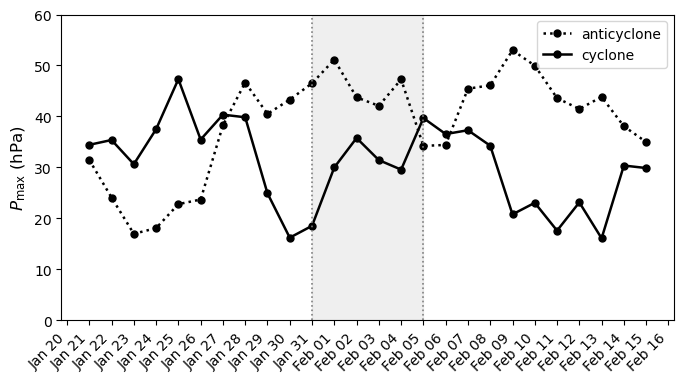

Saved: Pmax.png


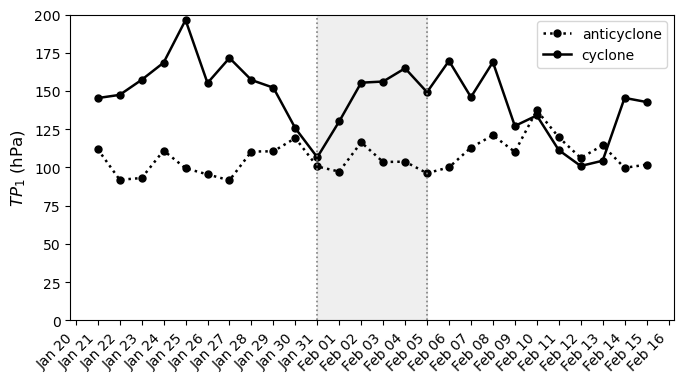

Saved: TP1.png


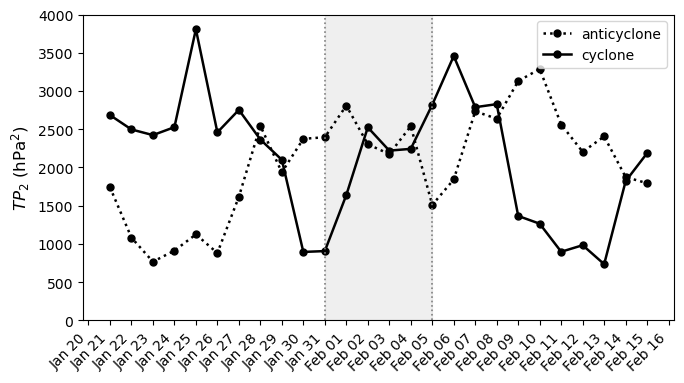

Saved: TP2.png


In [33]:
# ── P_max, TP_1, TP_2  —  one figure per metric ─────────────────────────────
metrics = [
    ('P_max', r'$P_{\max}$ (hPa)',   'Pmax.png', PMAX_YMAX),
    ('TP_1',  r'$TP_1$ (hPa)',       'TP1.png',  TP1_YMAX),
    ('TP_2',  r'$TP_2$ (hPa$^{2}$)', 'TP2.png',  TP2_YMAX),
]

for col, ylabel, fname, ymax in metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    for dtype, label in [('sub', 'cyclone'), ('sup', 'anticyclone')]:
        row = summary[summary['data_type'] == dtype].sort_values('date')
        ax.plot(row['date'], row[col], **STYLES[dtype])
    shade_event(ax)
    fmt_xaxis(ax)
    ax.set_ylabel(ylabel)
    if ymax is not None:
        ax.set_ylim(0, ymax)
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, fname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

---
## Further Temporal Analyses

### 1. Number of cycles above a persistence threshold
$N_\tau(t) = \#\{\, i : |b_i - d_i| \geq \tau \,\}$

### 2. Wasserstein distance between consecutive persistence diagrams
$W_t = W_2\!\left(\mathrm{PD}_t,\, \mathrm{PD}_{t+1}\right)$

where $W_2$ is the 2-Wasserstein (bottleneck-style) distance from `persim`.
A spike in $W_t$ means the diagram changed substantially from day $t$ to $t+1$.

In [34]:
# ── N_tau : number of cycles with persistence >= tau ────────────────────────
TAU = 10.0   # hPa threshold

# Count per (day, data_type) — days with 0 qualifying features stay 0
n_tau_raw = (
    df_window[df_window['persistence'] >= TAU]
    .groupby(['date', 't_offset', 'event_phase', 'data_type'])
    .size()
    .reset_index(name='N_tau')
)

# Left-join onto the full grid so missing days appear as 0
grid = summary[['date', 't_offset', 'event_phase', 'data_type']].copy()
n_tau_df = grid.merge(n_tau_raw, on=['date', 't_offset', 'event_phase', 'data_type'], how='left')
n_tau_df['N_tau'] = n_tau_df['N_tau'].fillna(0).astype(int)
n_tau_df = n_tau_df.sort_values(['t_offset', 'data_type']).reset_index(drop=True)

print(f'Threshold τ = {TAU} hPa')
n_tau_df[['date', 't_offset', 'event_phase', 'data_type', 'N_tau']]


Threshold τ = 10.0 hPa


,date,t_offset,event_phase,data_type,N_tau
0,2012-01-21,-10,pre-event,sub,3
1,2012-01-21,-10,pre-event,sup,3
2,2012-01-22,-9,pre-event,sub,3
3,2012-01-22,-9,pre-event,sup,3
4,2012-01-23,-8,pre-event,sub,2
5,2012-01-23,-8,pre-event,sup,6
6,2012-01-24,-7,pre-event,sub,3
7,2012-01-24,-7,pre-event,sup,4
8,2012-01-25,-6,pre-event,sub,3
9,2012-01-25,-6,pre-event,sup,7


In [35]:
import persim

# ── Wasserstein distance between consecutive daily persistence diagrams ───────
t_offsets = sorted(df_window['t_offset'].unique())

def get_diagram(t_off, dtype):
    """Return Nx2 array of (birth, death) for one day; empty diagram if no data."""
    sub = df_window[(df_window['t_offset'] == t_off) & (df_window['data_type'] == dtype)]
    if sub.empty:
        return np.empty((0, 2))
    return sub[['birth', 'death']].values.astype(float)

wass_records = []
for dtype in ['sub', 'sup']:
    for i in range(len(t_offsets) - 1):
        t_from, t_to = t_offsets[i], t_offsets[i + 1]
        D1 = get_diagram(t_from, dtype)
        D2 = get_diagram(t_to,   dtype)

        # persim requires at least one point in each diagram
        if len(D1) == 0 or len(D2) == 0:
            w_dist = np.nan
        else:
            w_dist = persim.wasserstein(D1, D2)

        wass_records.append({
            't_from':          t_from,
            't_to':            t_to,
            't_mid':           (t_from + t_to) / 2,
            'data_type':       dtype,
            'wasserstein_dist': w_dist,
        })

wass_df = pd.DataFrame(wass_records)
print('Wasserstein distances computed for', len(wass_df), 'consecutive day pairs')
wass_df


Wasserstein distances computed for 50 consecutive day pairs


,t_from,t_to,t_mid,data_type,wasserstein_dist
0,-10,-9,-9.5,sub,58.459659
1,-9,-8,-8.5,sub,41.195873
2,-8,-7,-7.5,sub,52.673014
3,-7,-6,-6.5,sub,58.285613
4,-6,-5,-5.5,sub,59.060764
5,-5,-4,-4.5,sub,55.849036
6,-4,-3,-3.5,sub,57.295066
7,-3,-2,-2.5,sub,46.660571
8,-2,-1,-1.5,sub,45.732094
9,-1,0,-0.5,sub,45.557007


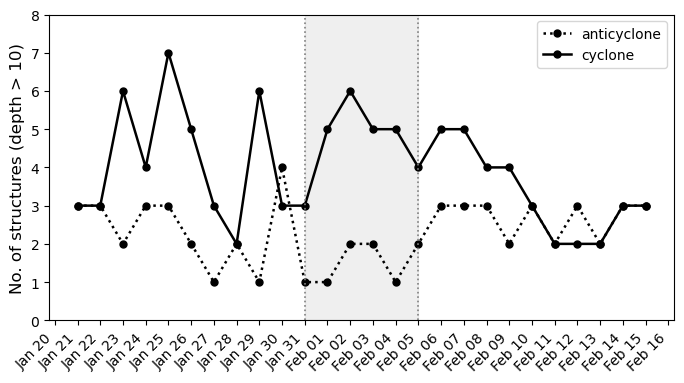

Saved: count_features_persistence_above_10hPa.png


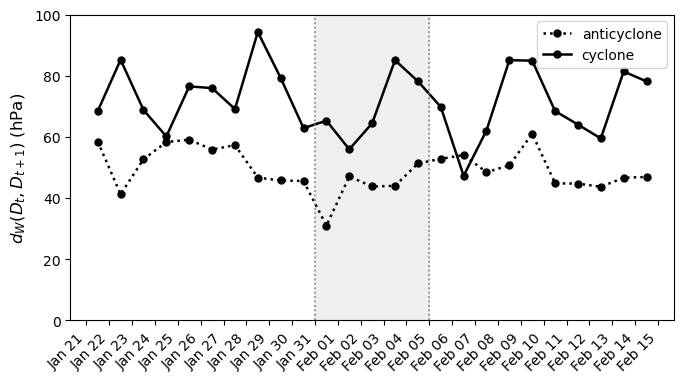

Saved: wasserstein.png


In [36]:
# ── N_tau  ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for dtype in ['sub', 'sup']:
    row = n_tau_df[n_tau_df['data_type'] == dtype].sort_values('date')
    ax.plot(row['date'], row['N_tau'], **STYLES[dtype])
shade_event(ax)
fmt_xaxis(ax)
ax.set_ylabel('No. of structures (depth > 10)')
if N_TAU_YMAX is not None:
    ax.set_ylim(0, N_TAU_YMAX)
ax.legend()
plt.tight_layout()
ntau_fname = f'count_features_persistence_above_{int(TAU)}hPa.png'
fig.savefig(os.path.join(out_dir, ntau_fname), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {ntau_fname}')

# ── Wasserstein distance ──────────────────────────────────────────────────────
wass_df['date_mid'] = wass_df['t_mid'].apply(
    lambda t: EVENT_START + pd.Timedelta(days=t)
)

fig, ax = plt.subplots(figsize=(7, 4))
for dtype in ['sub', 'sup']:
    row = wass_df[wass_df['data_type'] == dtype].sort_values('date_mid')
    ax.plot(row['date_mid'], row['wasserstein_dist'], **STYLES[dtype])
shade_event(ax)
fmt_xaxis(ax)
ax.set_ylabel(r'$d_W(D_t,D_{t+1})$ (hPa)')
if WASS_YMAX is not None:
    ax.set_ylim(0, WASS_YMAX)
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(out_dir, 'wasserstein.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: wasserstein.png')

---
## Spatial Area of the $P_{\max}$ Cycle

Each day we identify the feature achieving $P_{\max}$ and compute the geographic
area (km²) enclosed by its representative 1-cycle using the convex hull of the
cycle's vertices projected onto the WGS-84 ellipsoid.

This gives a direct physical measure of how large the dominant topological
structure is — before, during, and after the blocking event.

In [37]:
# ── Identify P_max feature per (day, data_type) and compute its area ─────────

# 'representative' column holds the edge list of the 1-cycle
# feature_tracking.compute_representative_area_km2 converts it to km²

area_records = []

for (t_off, dtype), grp in df_window.groupby(['t_offset', 'data_type']):
    # Row with maximum persistence
    pmax_row = grp.loc[grp['persistence'].idxmax()]

    area_km2 = feature_tracking.compute_representative_area_km2(
        pmax_row['representative'],
        matrix_size=172,
        lat_range=(0, 90),
        lon_range=(0, 360)
    )

    area_records.append({
        'date':          pmax_row['date'],
        't_offset':      t_off,
        'event_phase':   pmax_row['event_phase'],
        'data_type':     dtype,
        'feature_index': int(pmax_row['feature_index']),
        'P_max':         pmax_row['persistence'],
        'area_km2':      area_km2,
    })

area_df = (
    pd.DataFrame(area_records)
    .sort_values(['t_offset', 'data_type'])
    .reset_index(drop=True)
)

area_df


,date,t_offset,event_phase,data_type,feature_index,P_max,area_km2
0,2012-01-21,-10,pre-event,sub,80,31.471645,1.746180e+07
1,2012-01-21,-10,pre-event,sup,96,34.431087,2.818861e+07
2,2012-01-22,-9,pre-event,sub,91,24.085229,1.047810e+06
3,2012-01-22,-9,pre-event,sup,101,35.378384,9.293017e+07
4,2012-01-23,-8,pre-event,sub,112,16.972776,2.141607e+07
5,2012-01-23,-8,pre-event,sup,84,30.631591,1.201159e+08
6,2012-01-24,-7,pre-event,sub,138,18.087772,1.743933e+06
7,2012-01-24,-7,pre-event,sup,125,37.494035,1.665623e+08
8,2012-01-25,-6,pre-event,sub,87,22.793439,6.648164e+06
9,2012-01-25,-6,pre-event,sup,101,47.313471,2.220118e+08


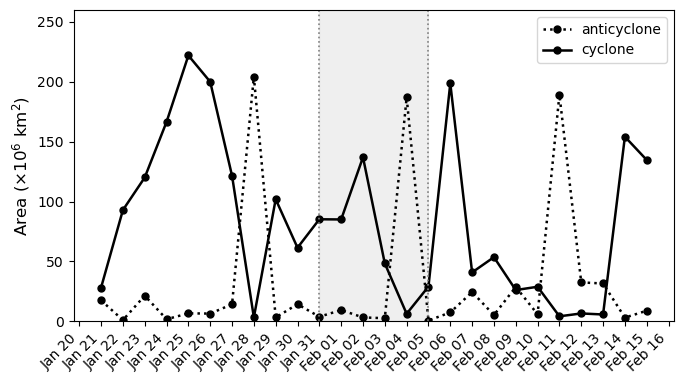

Saved: area_most_persistent_feature.png


In [38]:
# ── Area of most persistent feature — cyclone and anticyclone in one figure ──
fig, ax = plt.subplots(figsize=(7, 4))

for dtype in ['sub', 'sup']:
    row = area_df[area_df['data_type'] == dtype].sort_values('date')
    ax.plot(row['date'], row['area_km2'] / 1e6, **STYLES[dtype])

shade_event(ax)
fmt_xaxis(ax)
ax.set_ylabel(r'Area ($\times 10^6$ km$^2$)')
if AREA_YMAX is not None:
    ax.set_ylim(0, AREA_YMAX)
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(out_dir, 'area_most_persistent_feature.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: area_most_persistent_feature.png')

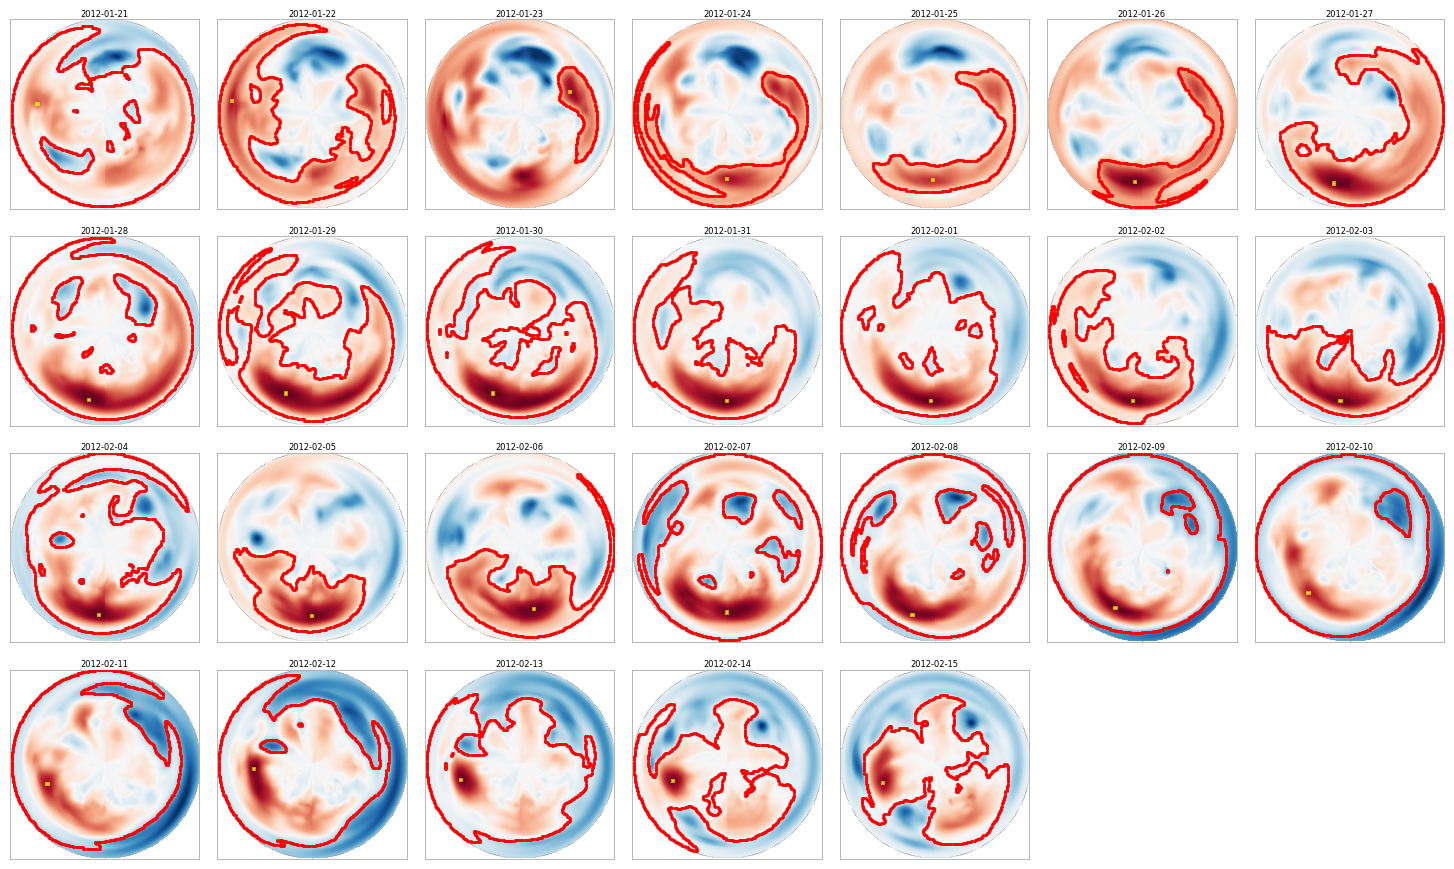

Saved: pmax_cycle_evolution_sub.png


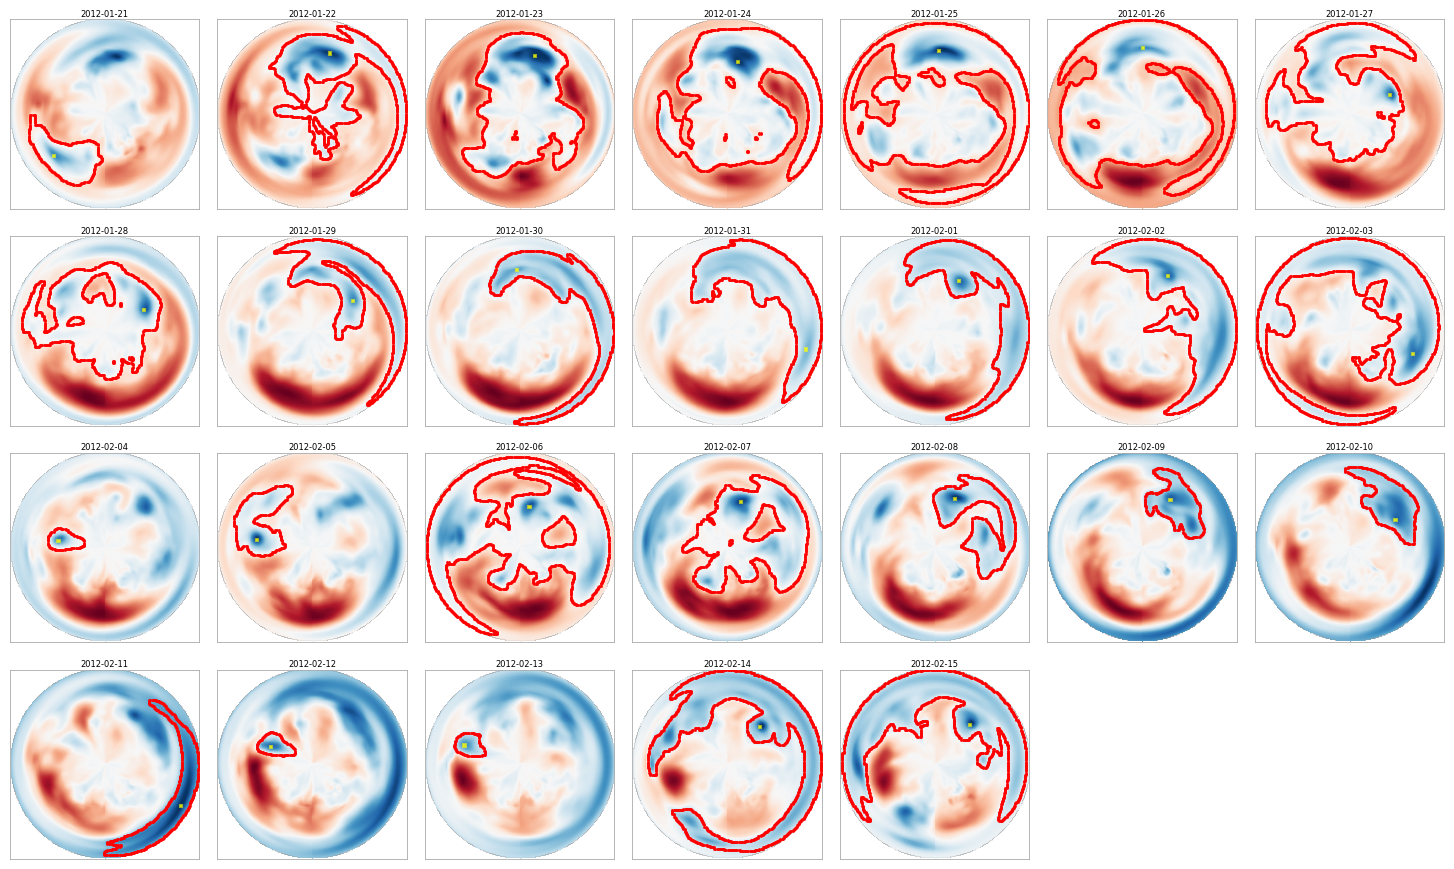

Saved: pmax_cycle_evolution_sup.png


In [39]:
# ── Plot P_max representative 1-cycle for every day in the event window ──────
# One figure per data_type (sub / sup), 26 panels arranged in a 4×7 grid.
# Each panel: polar SLP heatmap + representative edges (yellow) + death square (yellow box) + vertices (red).

from matplotlib.patches import Rectangle

data_base = os.path.join(notebook_directory, 'data', 'processed_data', 'SLP_data_years')

rep_lookup = (
    df_window
    .set_index(['t_offset', 'data_type', 'feature_index'])['representative']
)
death_lookup = (
    df_window
    .set_index(['t_offset', 'data_type', 'feature_index'])['death_simplex_vertices']
)

NCOLS    = 7
PANEL_SZ = 2.1

for dtype in ['sub', 'sup']:
    rows_for_type = (
        area_df[area_df['data_type'] == dtype]
        .sort_values('t_offset')
        .reset_index(drop=True)
    )
    n     = len(rows_for_type)
    nrows = (n + NCOLS - 1) // NCOLS

    fig, axes = plt.subplots(nrows, NCOLS,
                             figsize=(NCOLS * PANEL_SZ, nrows * PANEL_SZ + 0.5))
    axes = axes.flatten()

    for ax_idx, (_, row) in enumerate(rows_for_type.iterrows()):
        ax      = axes[ax_idx]
        t_off   = int(row['t_offset'])
        feat_id = int(row['feature_index'])
        date_ts = row['date']
        year    = date_ts.year
        doy     = (date_ts - pd.Timestamp(f'{year}-01-01')).days + 1

        # ── background heatmap ──────────────────────────────────────────────
        npy_path = os.path.join(data_base, str(year),
                                f'slp_{dtype}_{year}_day_{doy}.npy')
        if os.path.exists(npy_path):
            mat = np.load(npy_path).astype(float)
            if dtype == 'sup':
                mat = -mat
            h, w   = mat.shape
            cx, cy = w // 2, h // 2
            yi, xi = np.ogrid[:h, :w]
            mat[((xi - cx)**2 + (yi - cy)**2) > cx**2] = np.nan
            vmax = np.nanmax(np.abs(mat))
            ax.imshow(mat / 100.0, cmap='RdBu_r', origin='lower',
                      vmin=-vmax / 100.0, vmax=vmax / 100.0, aspect='equal')
        else:
            ax.set_facecolor('#dddddd')

        key = (t_off, dtype, feat_id)

        # ── representative edges ─────────────────────────────────────────────
        if key in rep_lookup.index:
            rep = rep_lookup[key]
            if rep:
                all_verts = set()
                for edge in rep:
                    if len(edge) == 2:
                        r1, c1 = edge[0]
                        r2, c2 = edge[1]
                        ax.plot([c1, c2], [r1, r2],
                                color='yellow', lw=0.7, alpha=0.8, zorder=2)
                        all_verts.add((r1, c1))
                        all_verts.add((r2, c2))
                if all_verts:
                    vr, vc = zip(*all_verts)
                    ax.scatter(vc, vr, c='red', s=4, zorder=3, linewidths=0)

        # ── death square ─────────────────────────────────────────────────────
        if key in death_lookup.index:
            dsv = death_lookup[key]
            if dsv and len(dsv) == 4:
                dr = [v[0] for v in dsv]
                dc = [v[1] for v in dsv]
                rect = Rectangle((min(dc) - 0.5, min(dr) - 0.5),
                                  max(dc) - min(dc) + 1, max(dr) - min(dr) + 1,
                                  linewidth=1.5, edgecolor='yellow', facecolor='yellow',
                                  alpha=0.6, zorder=4)
                ax.add_patch(rect)

        # ── border ───────────────────────────────────────────────────────────
        for spine in ax.spines.values():
            spine.set_edgecolor('#aaaaaa')
            spine.set_linewidth(0.6)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(date_ts.strftime('%Y-%m-%d'), fontsize=6, pad=2)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    fname = f'pmax_cycle_evolution_{dtype}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')